# RAGAS Evaluation

> **Run notes**\n> - Judge LLMs: `gpt-4o` (pre-registered) and `gpt-4o-mini` (fallback that runs here), both temperature 0.\n> - `N_RUNS = 3`: each judge evaluates the full set 3×. Reported **SD is across runs** (judge variance), not across questions.\n> - Contexts scored are `contexts_clean` (embedding arrays stripped, rows deduped, section tags kept).\n> - Context Precision / Recall / Faithfulness / Noise Sensitivity are **within-system diagnostics only** — do not cross-compare with VRAG. Cross-system: Answer Accuracy, Response Relevancy, section-citation recall.\n> - API key is read from `.env` via `os.getenv`; never hardcode it.

- evaluate for every question (each row, each question, each evaluation record)
- evaluate for all question (for conclusion)

In [1]:
# check if GPU is available
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
# Read the key from the environment / .env file. NEVER hardcode it in the notebook.
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
# assert OPENAI_API_KEY, "OPENAI_API_KEY not found. Put it in a .env file (and add .env to .gitignore)."

In [3]:
# Sanity check WITHOUT exposing the key:
print("OPENAI_API_KEY loaded:", bool(OPENAI_API_KEY))

OPENAI_API_KEY loaded: True


In [4]:
import pandas as pd
from datasets import Dataset

In [5]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import LLMContextPrecisionWithReference, LLMContextRecall, ContextEntityRecall, NoiseSensitivity, ResponseRelevancy, Faithfulness, AnswerAccuracy
from ragas import SingleTurnSample
from ragas import evaluate
from ragas.metrics import answer_relevancy, faithfulness, context_precision, context_recall, context_entity_recall,  AnswerAccuracy

## 1. Load the Evaluation Dataset

In [6]:
import os
print(os.getcwd())
print(os.listdir())

/home/jupyter-dsai-st124087/Evaluation - Final - Vector
['3.1 modelsEvaluation-vrag_fixed.ipynb', '.ipynb_checkpoints', 'vectorRAG_eval_ready.xlsx']


In [7]:
# Use the parity-cleaned contexts (embedding arrays stripped, rows deduped,
# section tags preserved). Original raw contexts remain in the 'contexts' column
# of the source file if you want to compare.
df_4omini = pd.read_excel("vectorRAG_eval_ready.xlsx", sheet_name="vector_results")

# Score the CLEANED contexts. Keep a copy of raw in case you want the ablation.
df_4omini["contexts_raw"] = df_4omini["contexts"]
# df_4omini["contexts"] = df_4omini["contexts_clean"]

In [8]:
df_4omini[:3]

,id,question,idx,mode,answer,ground_truth,contexts,contexts_raw
0,PDPA-001,What is PDPA?,1,vector,"The Personal Data Protection Act, B.E. 2562 (2...","PDPA (Personal Data Protection Act, B.E. 2562 ...","[""Section 6 In this Act,\n“Personal Data” mean...","[""Section 6 In this Act,\n“Personal Data” mean..."
1,PDPA-002,What is personal data?,2,vector,Personal data is defined as any information re...,Information about an individual that enables t...,"[""Section 6 In this Act,\n“Personal Data” mean...","[""Section 6 In this Act,\n“Personal Data” mean..."
2,PDPA-003,What is a personal data protection policy?,3,vector,A personal data protection policy is a framewo...,A personal data protection policy is a policy ...,"[""(5) where it is to prevent or suppress a dan...","[""(5) where it is to prevent or suppress a dan..."


In [9]:
# df_4omini.columns

In [10]:
# len(df_4omini)

## 2. Define the models and metrics

In [11]:
from langchain_ollama import OllamaEmbeddings
# call ollama embedding langchain
embeddings = OllamaEmbeddings(model = 'nomic-embed-text', base_url="http://localhost:11434")

In [12]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI

# Embedding wrapper (used by ResponseRelevancy)
embeddings = LangchainEmbeddingsWrapper(embeddings=embeddings)

# Two judge LLMs, both at temperature 0.
# NOTE: gpt-4o is the pre-registered judge; gpt-4o-mini is the fallback that
# actually runs in this environment. Report clearly which one produced the
# numbers you cite in the thesis.
llm_4o = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4o", api_key=OPENAI_API_KEY, temperature=0)
)
llm_4omini = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4o-mini", api_key=OPENAI_API_KEY, temperature=0)
)

In [13]:
# Build metrics bound to a given judge LLM.
# Metrics are constructed per-judge because each holds a reference to its llm.
def build_metrics(judge_llm):
    return {
        "Context Precision":  LLMContextPrecisionWithReference(llm=judge_llm),
        "Context Recall":     LLMContextRecall(llm=judge_llm),
        "Noise Sensitivity":  NoiseSensitivity(llm=judge_llm),
        "Response Relevancy": ResponseRelevancy(llm=judge_llm, embeddings=embeddings),
        "Faithfulness":       Faithfulness(llm=judge_llm),
        "Answer Accuracy":    AnswerAccuracy(llm=judge_llm),
    }

## 3. Evaluate (calculate the metrics) for each question

### 3.1 Evaluate Function

In [14]:
import pandas as pd
from ragas.dataset_schema import SingleTurnSample

def normalize_contexts(cell):
    """
    contexts_clean stores one node/chunk per line (prose, section-tagged).
    Split into a list of non-empty strings. Also tolerates an actual list.
    """
    if isinstance(cell, list):
        return [str(x).strip() for x in cell if str(x).strip()]
    s = "" if cell is None else str(cell)
    return [ln.strip() for ln in s.split("\n") if ln.strip()]


def evaluate_row(row, metrics):
    contexts = normalize_contexts(row["contexts"])
    sample = SingleTurnSample(
        user_input=row["question"],
        reference=row["ground_truth"],
        retrieved_contexts=contexts,
        response=row["answer"],
    )
    results = {}
    for metric_name, metric in metrics.items():
        try:
            results[metric_name] = metric.single_turn_score(sample)
        except Exception as e:
            results[metric_name] = f"Error: {e}"
    return results

In [15]:
# Evaluate the whole dataframe once (one judging pass).
def evaluate_dataframe(df, metrics):
    results = []
    for _, row in df.iterrows():
        results.append(evaluate_row(row, metrics))
    return pd.DataFrame(results)


import numpy as np

def run_n_times(df, judge_llm, n_runs=3, judge_name="judge"):
    """
    Run the full evaluation n_runs times with a given judge.
    Returns:
      per_run   : list of per-row DataFrames (one per run)
      summary   : DataFrame with per-metric Average Score and Standard Deviation
                  where SD is computed ACROSS RUNS on the per-run means
                  (i.e. LLM-judge variance, which is what the methodology claims).
    """
    metrics = build_metrics(judge_llm)
    per_run = []
    run_means = []
    for r in range(n_runs):
        print(f"[{judge_name}] run {r+1}/{n_runs} ...")
        res = evaluate_dataframe(df, metrics)
        # coerce any 'Error: ...' strings to NaN so they don't poison the mean
        res_num = res.apply(pd.to_numeric, errors="coerce")
        per_run.append(res_num)
        run_means.append(res_num.mean(numeric_only=True))

    means_by_run = pd.DataFrame(run_means)          # rows = runs, cols = metrics
    summary = pd.DataFrame({
        "Metric": means_by_run.columns,
        "Average Score": means_by_run.mean().round(3).values,       # mean of run-means
        "Standard Deviation": means_by_run.std(ddof=1).round(3).values,  # across-run SD
        "n_runs": n_runs,
        "judge": judge_name,
    })
    return per_run, summary


N_RUNS = 3

### 3.2 Evaluation (model evaluation)

#### model 1: 4omini

In [16]:
from ragas.run_config import RunConfig

run_config = RunConfig(
    timeout=180,
    max_retries=10,
    max_wait=60,
    max_workers=1
)

In [17]:
# Run BOTH judges, 3 runs each.
# gpt-4o-mini is expected to complete; gpt-4o may fail in this environment.
per_run_4omini, summary_4omini = run_n_times(
    df_4omini, llm_4omini, n_runs=N_RUNS, judge_name="gpt-4o-mini"
)

# try:
#     per_run_4o, summary_4o = run_n_times(
#         df_4omini, llm_4o, n_runs=N_RUNS, judge_name="gpt-4o"
#     )
#     gpt4o_ok = True
# except Exception as e:
#     print("gpt-4o judge failed, keeping gpt-4o-mini results only:", e)
#     per_run_4o, summary_4o, gpt4o_ok = None, None, False

[gpt-4o-mini] run 1/3 ...
[gpt-4o-mini] run 2/3 ...
[gpt-4o-mini] run 3/3 ...


In [18]:
for r, dfr in enumerate(per_run_4omini):
    print(f"run {r+1}: NaN counts per metric")
    print(dfr.isna().sum())
    print()
print(summary_4omini)

run 1: NaN counts per metric
Context Precision     0
Context Recall        0
Noise Sensitivity     0
Response Relevancy    0
Faithfulness          0
Answer Accuracy       0
dtype: int64

run 2: NaN counts per metric
Context Precision     0
Context Recall        0
Noise Sensitivity     0
Response Relevancy    0
Faithfulness          0
Answer Accuracy       0
dtype: int64

run 3: NaN counts per metric
Context Precision     0
Context Recall        0
Noise Sensitivity     0
Response Relevancy    0
Faithfulness          0
Answer Accuracy       0
dtype: int64

               Metric  Average Score  Standard Deviation  n_runs        judge
0   Context Precision          0.810               0.016       3  gpt-4o-mini
1      Context Recall          0.342               0.001       3  gpt-4o-mini
2   Noise Sensitivity          0.268               0.003       3  gpt-4o-mini
3  Response Relevancy          0.751               0.002       3  gpt-4o-mini
4        Faithfulness          0.740             

In [19]:
print("gpt-4o-mini summary (mean over runs, SD across runs):")
print(summary_4omini)
# if gpt4o_ok:
#     print("\ngpt-4o summary:")
#     print(summary_4o)

gpt-4o-mini summary (mean over runs, SD across runs):
               Metric  Average Score  Standard Deviation  n_runs        judge
0   Context Precision          0.810               0.016       3  gpt-4o-mini
1      Context Recall          0.342               0.001       3  gpt-4o-mini
2   Noise Sensitivity          0.268               0.003       3  gpt-4o-mini
3  Response Relevancy          0.751               0.002       3  gpt-4o-mini
4        Faithfulness          0.740               0.009       3  gpt-4o-mini
5     Answer Accuracy          0.329               0.007       3  gpt-4o-mini


In [20]:
# Save per-run detail and the run-averaged summaries for both judges.
with pd.ExcelWriter("graphRAG_evaluationResult.xlsx") as writer:
    for r, dfr in enumerate(per_run_4omini):
        dfr.to_excel(writer, sheet_name=f"4omini_run{r+1}", index=False)
    summary_4omini.to_excel(writer, sheet_name="4omini_summary", index=False)
    # if gpt4o_ok:
    #     for r, dfr in enumerate(per_run_4o):
    #         dfr.to_excel(writer, sheet_name=f"4o_run{r+1}", index=False)
    #     summary_4o.to_excel(writer, sheet_name="4o_summary", index=False)
print("Saved graphRAG_evaluationResult.xlsx")

Saved graphRAG_evaluationResult.xlsx


## 4. Evaluate metric AVG score

In [21]:
import matplotlib.pyplot as plt

In [22]:
# # Plot grouped bar chart
# ax = df_summary.plot(kind="bar", figsize=(10, 6))
# plt.title("Average Evaluation Metrics per Model")
# plt.ylabel("Score")
# plt.xticks(rotation=0)
# plt.legend(title="Metrics")
# plt.tight_layout()
# plt.show()

In [23]:
with pd.ExcelWriter("evaluationResult_average.xlsx") as writer:
    summary_4omini.to_excel(writer, sheet_name="gpt-4o-mini", index=False)
    # if gpt4o_ok:
    #     summary_4o.to_excel(writer, sheet_name="gpt-4o", index=False)
print("Saved: evaluationResult_average.xlsx")

Saved: evaluationResult_average.xlsx


In [24]:
# df_summary already produced by run_n_times (mean over runs, SD across runs).
df_summary = summary_4omini.copy()
print(df_summary)

               Metric  Average Score  Standard Deviation  n_runs        judge
0   Context Precision          0.810               0.016       3  gpt-4o-mini
1      Context Recall          0.342               0.001       3  gpt-4o-mini
2   Noise Sensitivity          0.268               0.003       3  gpt-4o-mini
3  Response Relevancy          0.751               0.002       3  gpt-4o-mini
4        Faithfulness          0.740               0.009       3  gpt-4o-mini
5     Answer Accuracy          0.329               0.007       3  gpt-4o-mini


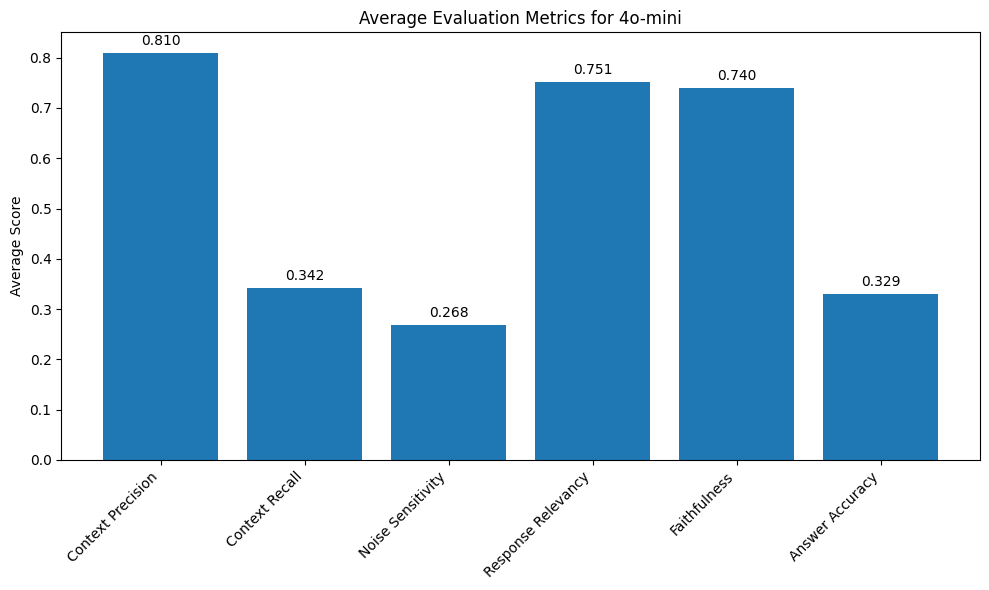

In [25]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df_summary["Metric"], df_summary["Average Score"])

plt.title("Average Evaluation Metrics for 4o-mini")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")

# Add value labels on top of bars
for bar, value in zip(bars, df_summary["Average Score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

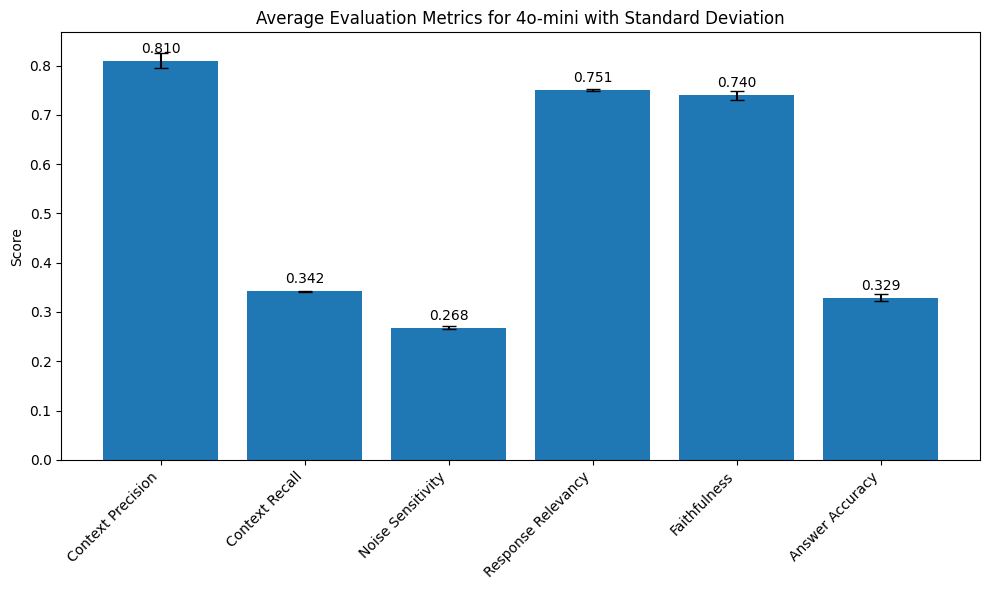

In [26]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    df_summary["Metric"],
    df_summary["Average Score"],
    yerr=df_summary["Standard Deviation"],
    capsize=5
)

plt.title("Average Evaluation Metrics for 4o-mini with Standard Deviation")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")

# Add mean labels
for bar, value in zip(bars, df_summary["Average Score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Evaluation

What's working well  
- The retrieval side looks solid in terms of precision.  
- Context Precision at 0.80 means the system is pulling mostly relevant chunks — it's not flooding the context window with noise.
- Response Relevancy (0.73) and
- Faithfulness (0.73) are also healthy, indicating the model is staying on-topic and grounding its answers in the retrieved content rather than hallucinating.

Where the system is struggling  
- Context Recall at 0.34 is the most critical weakness. This means the retriever is frequently missing relevant source chunks — it finds some of the right documents, but not enough of them. The answer can't be complete if the context is incomplete.
- Answer Accuracy at 0.39 is the downstream consequence of that. Even when the model is faithful to what it retrieved, if the retrieved context is incomplete, the final answers will be wrong or partial.
- Noise Sensitivity at 0.27 seems low (good — it means the model isn't easily thrown off by irrelevant context), but given the high standard deviation on Context Precision (0.406), there's likely high inconsistency across queries. Some queries get very clean retrieval, others don't.

The core diagnosis  
There's a precision–recall imbalance in retrieval. The system is conservative — it fetches high-quality but insufficient context. This points to issues like:
- Chunk size being too small (relevant info split across chunks, only some retrieved)
- Top-k being too low (not fetching enough candidates)
- Embedding model struggling with recall for certain query types

Context Precision jumped from 0.171 → 0.400, Context Recall from 0.136 → 0.415, Faithfulness from 0.086 → 0.676. That's a large, consistent lift, and it confirms what we suspected: your original low scores were substantially an artifact of the broken normalizer silently emptying the graph contexts, plus the serialization noise. Faithfulness at 0.676 is a completely different picture from 0.086 — the answers were always more grounded than the old number implied; the judge just couldn't see the context properly before. This is the payoff of fixing the normalizer + cleaning, and it's honestly reportable as such.

## To get the Response Relevancy Results

In [27]:
# print(embeddings.embed_query("test")[:5])  # should print 5 floats, not error

In [28]:
def run_relevancy_only(df, judge_llm, n_runs=3):
    metric = ResponseRelevancy(llm=judge_llm, embeddings=embeddings)
    means = []
    for r in range(n_runs):
        print(f"relevancy run {r+1}/{n_runs}")
        vals = []
        for _, row in df.iterrows():
            s = SingleTurnSample(
                user_input=row["question"], reference=row["ground_truth"],
                retrieved_contexts=normalize_contexts(row["contexts"]),
                response=row["answer"],
            )
            try: vals.append(metric.single_turn_score(s))
            except Exception: vals.append(float("nan"))
        means.append(pd.Series(vals).mean())
    return round(pd.Series(means).mean(),3), round(pd.Series(means).std(ddof=1),3)

avg, sd = run_relevancy_only(df_4omini, llm_4omini, n_runs=3)
print("Response Relevancy:", avg, "±", sd)

relevancy run 1/3
relevancy run 2/3
relevancy run 3/3
Response Relevancy: 0.729 ± 0.001


In [29]:
# row = df_4omini.iloc[0]
# s = SingleTurnSample(
#     user_input=row["question"],
#     reference=row["ground_truth"],
#     retrieved_contexts=normalize_contexts(row["contexts"]),
#     response=row["answer"],
# )
# metric = ResponseRelevancy(llm=llm_4omini, embeddings=embeddings)
# score = metric.single_turn_score(s)   # no try/except — let it raise
# print("Response Relevancy (row 0):", score)

In [30]:
import pandas as pd

# Start from the five-metric summary you already have
final = summary_4omini.copy()

# Fill in the Response Relevancy row (was NaN) with the values you just got
mask = final["Metric"] == "Response Relevancy"
final.loc[mask, "Average Score"] = avg
final.loc[mask, "Standard Deviation"] = sd

# tidy column order
final = final[["Metric", "Average Score", "Standard Deviation", "n_runs", "judge"]]
print(final)

final.to_excel("graphRAG_final_metrics_4omini.xlsx", index=False)
print("Saved graphRAG_final_metrics_4omini.xlsx")

               Metric  Average Score  Standard Deviation  n_runs        judge
0   Context Precision          0.810               0.016       3  gpt-4o-mini
1      Context Recall          0.342               0.001       3  gpt-4o-mini
2   Noise Sensitivity          0.268               0.003       3  gpt-4o-mini
3  Response Relevancy          0.729               0.001       3  gpt-4o-mini
4        Faithfulness          0.740               0.009       3  gpt-4o-mini
5     Answer Accuracy          0.329               0.007       3  gpt-4o-mini
Saved graphRAG_final_metrics_4omini.xlsx


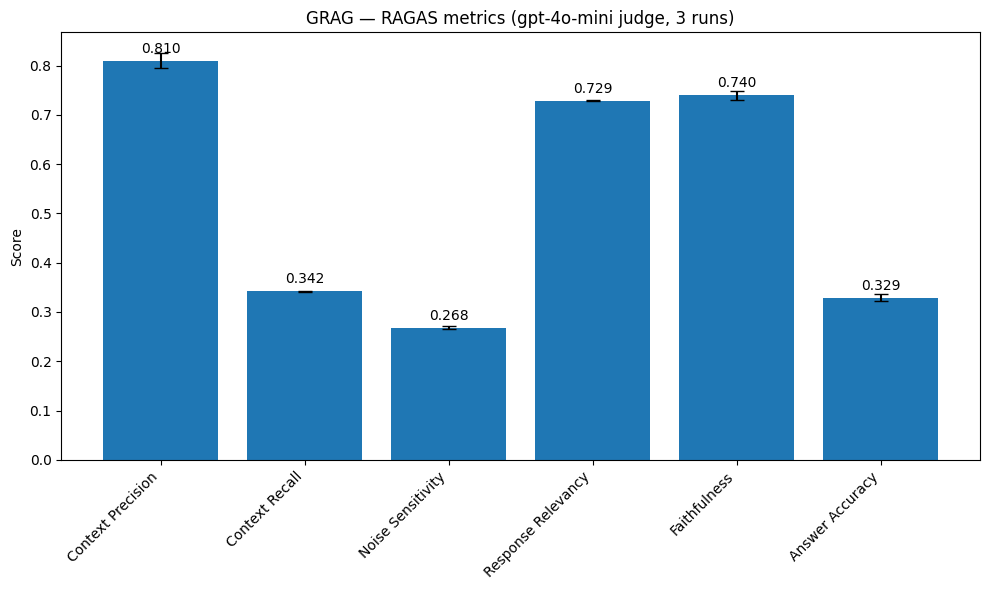

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
bars = plt.bar(final["Metric"], final["Average Score"],
               yerr=final["Standard Deviation"], capsize=5)
plt.title("GRAG — RAGAS metrics (gpt-4o-mini judge, 3 runs)")
plt.ylabel("Score"); plt.xticks(rotation=45, ha="right")
for b,v in zip(bars, final["Average Score"]):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## rerun For saving the data

In [32]:
import pandas as pd

def run_relevancy_detailed(df, judge_llm, n_runs=3):
    metric = ResponseRelevancy(llm=judge_llm, embeddings=embeddings)
    per_run = {}          # each run's per-row scores
    run_means = []
    for r in range(n_runs):
        print(f"relevancy run {r+1}/{n_runs}")
        vals = []
        for _, row in df.iterrows():
            s = SingleTurnSample(
                user_input=row["question"], reference=row["ground_truth"],
                retrieved_contexts=normalize_contexts(row["contexts"]),
                response=row["answer"],
            )
            try: vals.append(metric.single_turn_score(s))
            except Exception: vals.append(float("nan"))
        per_run[f"run{r+1}"] = vals
        run_means.append(pd.Series(vals).mean())

    # table: one row per question, one column per run
    detail = pd.DataFrame(per_run)
    detail.insert(0, "question", df["question"].values)

    # summary: mean of each run, then overall mean and SD across runs
    summary = pd.DataFrame({
        "run": [f"run{i+1}" for i in range(n_runs)],
        "mean_score": [round(m, 3) for m in run_means],
    })
    overall_avg = round(pd.Series(run_means).mean(), 3)
    overall_sd  = round(pd.Series(run_means).std(ddof=1), 3)
    return detail, summary, overall_avg, overall_sd


detail, summary, avg, sd = run_relevancy_detailed(df_4omini, llm_4omini, n_runs=3)

print("Per-run means:")
print(summary)
print(f"\nOverall Response Relevancy: {avg} ± {sd}")
print("\nPer-question scores (first rows):")
print(detail.head())

relevancy run 1/3
relevancy run 2/3
relevancy run 3/3
Per-run means:
    run  mean_score
0  run1       0.750
1  run2       0.729
2  run3       0.750

Overall Response Relevancy: 0.743 ± 0.012

Per-question scores (first rows):
                                      question      run1      run2      run3
0                                What is PDPA?  0.574469  0.572304  0.568446
1                       What is personal data?  0.944766  0.944766  0.944766
2   What is a personal data protection policy?  0.868720  0.868720  0.868720
3                 What is a privacy statement?  0.930496  0.930496  0.930496
4  What if there is no Data Protection Policy?  0.731689  0.000000  0.731689


In [33]:
with pd.ExcelWriter("graphRAG_relevancy_detail.xlsx") as w:
    summary.to_excel(w, sheet_name="per_run_means", index=False)
    detail.to_excel(w, sheet_name="per_question", index=False)
print("Saved graphRAG_relevancy_detail.xlsx")

Saved graphRAG_relevancy_detail.xlsx
